<a href="https://colab.research.google.com/github/lexie009/CBB6340/blob/main/6340_A1_Covid_Case_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [8]:
# load the data
url = "https://raw.githubusercontent.com/nytimes/covid-19-data/master/us-states.csv"
covid_data = pd.read_csv(url)

# Convert the date column to datetime
covid_data["date"] = pd.to_datetime(covid_data["date"])

# check some examples
display(covid_data.head())

# check how many states
num_states = covid_data["state"].nunique()
print(f"Number of unique states or territories: {num_states}")


state_names = sorted(covid_data["state"].unique())
print(state_names)




,date,state,fips,cases,deaths
0,2020-01-21,Washington,53,1,0
1,2020-01-22,Washington,53,1,0
2,2020-01-23,Washington,53,1,0
3,2020-01-24,Illinois,17,1,0
4,2020-01-24,Washington,53,1,0


Number of unique states or territories: 56
['Alabama', 'Alaska', 'American Samoa', 'Arizona', 'Arkansas', 'California', 'Colorado', 'Connecticut', 'Delaware', 'District of Columbia', 'Florida', 'Georgia', 'Guam', 'Hawaii', 'Idaho', 'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota', 'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada', 'New Hampshire', 'New Jersey', 'New Mexico', 'New York', 'North Carolina', 'North Dakota', 'Northern Mariana Islands', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania', 'Puerto Rico', 'Rhode Island', 'South Carolina', 'South Dakota', 'Tennessee', 'Texas', 'Utah', 'Vermont', 'Virgin Islands', 'Virginia', 'Washington', 'West Virginia', 'Wisconsin', 'Wyoming']


In [9]:


def plot_daily_cases(states):
    """
    Plot daily new COVID-19 cases for a list of U.S. states.

    Parameters
    ----------
    states : list of str
    """

    # Check whether the requested states exist in the dataset
    valid_states = set(covid_data["state"].unique())
    invalid_states = [state for state in states if state not in valid_states]

    if invalid_states:
        raise ValueError(f"State names not found: {invalid_states}")

    plt.figure(figsize=(14, 7))

    for state in states:
        state_data = (
            covid_data[covid_data["state"] == state]
            .sort_values("date")
            .copy()
        )

        # Convert cumulative cases into daily new cases
        state_data["daily_cases"] = state_data["cases"].diff()

        # For the first recorded day, use the cumulative count
        state_data["daily_cases"] = state_data["daily_cases"].fillna(
            state_data["cases"]
        )

        plt.plot(
            state_data["date"],
            state_data["daily_cases"],
            label=state,
            linewidth=1
        )

    plt.xlabel("Date")
    plt.ylabel("Daily New Cases")
    plt.title("Daily New COVID-19 Cases by State")
    plt.legend()
    plt.grid(alpha=0.3)

    # Format the date axis
    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

    plt.xticks(rotation=45)
    plt.tight_layout()

    # Save the figure so it can be included in README.md
    plt.savefig("daily_new_cases.png", dpi=300, bbox_inches="tight")

    plt.show()

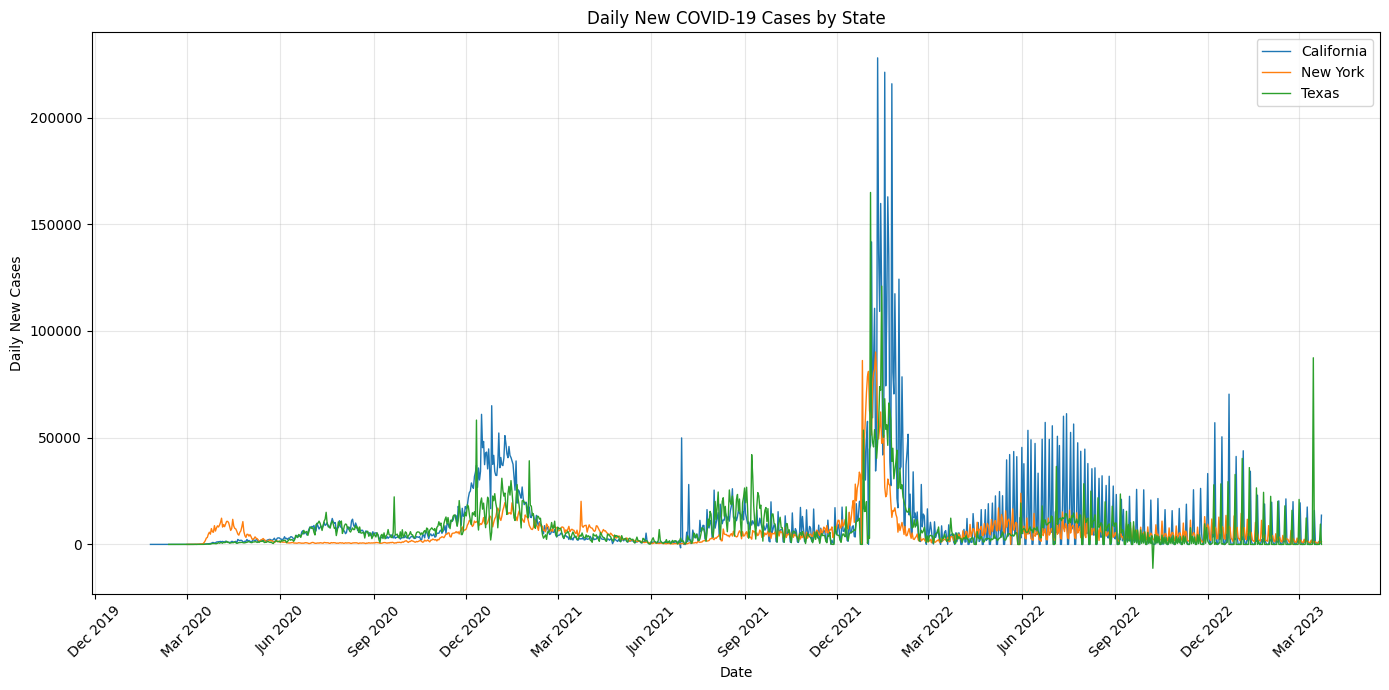

In [12]:
plot_daily_cases(["California","New York","Texas"])

In [13]:
# state experienced its highest number of daily new cases.
def find_peak_cases(state):
    valid_states = set(covid_data["state"].unique())

    if state not in valid_states:
        raise ValueError(f"State not found: {state}")

    state_data = (
        covid_data[covid_data["state"] == state]
        .sort_values("date")
        .copy()
    )

    state_data["daily_cases"] = (
        state_data["cases"]
        .diff()
        .fillna(state_data["cases"])
    )

    peak_row = state_data.loc[state_data["daily_cases"].idxmax()]

    return {
        "state": state,
        "date": peak_row["date"].strftime("%Y-%m-%d"),
        "daily_cases": int(peak_row["daily_cases"])
    }

In [14]:
# print peak cases for states
print(find_peak_cases("California"))
print(find_peak_cases("New York"))
print(find_peak_cases("Texas"))

{'state': 'California', 'date': '2022-01-10', 'daily_cases': 227972}
{'state': 'New York', 'date': '2022-01-08', 'daily_cases': 90132}
{'state': 'Texas', 'date': '2022-01-03', 'daily_cases': 164902}


In [21]:
def compare_peak_dates(state1, state2):
    peak_date1 = find_peak_cases(state1)
    peak_date2 = find_peak_cases(state2)


    peak_date1 = pd.to_datetime(peak_date1["date"])
    peak_date2 = pd.to_datetime(peak_date2["date"])

    days_between = abs((peak_date1 - peak_date2).days)

    if peak_date1 < peak_date2:
        first_state = state1
    elif peak_date2 < peak_date1:
        first_state = state2
    else:
        first_state = "Both states"

    print(f"{state1} peak date: {peak_date1.strftime('%Y-%m-%d')}")
    print(f"{state2} peak date: {peak_date2.strftime('%Y-%m-%d')}")
    print(f"{first_state} reached the peak first.")
    print(f"Days between peaks: {days_between}")
    print(f"")

In [24]:
result = compare_peak_dates("California", "New York")

California peak date: 2022-01-10
New York peak date: 2022-01-08
New York reached the peak first.
Days between peaks: 2


In [25]:
# Select Florida data
florida_data = (
    covid_data[covid_data["state"] == "Florida"]
    .sort_values("date")
    .copy()
)

# Calculate daily new cases
florida_data["daily_cases"] = (
    florida_data["cases"]
    .diff()
    .fillna(florida_data["cases"])
)

# Display the 10 largest daily case counts
print("Largest daily case counts:")
print(
    florida_data.nlargest(10, "daily_cases")[
        ["date", "daily_cases"]
    ]
)

# Display negative daily case counts
print("\nNegative daily case counts:")
print(
    florida_data[florida_data["daily_cases"] < 0][
        ["date", "daily_cases"]
    ]
)

Largest daily case counts:
            date  daily_cases
37088 2022-01-04     193786.0
37424 2022-01-10     125996.0
37872 2022-01-18     111621.0
57640 2023-01-06      80749.0
36808 2021-12-30      77848.0
37256 2022-01-07      76887.0
36864 2021-12-31      76392.0
36640 2021-12-27      71957.0
37536 2022-01-12      71742.0
37312 2022-01-08      69914.0

Negative daily case counts:
            date  daily_cases
25213 2021-06-04     -40527.0


In [26]:
print(
    florida_data[
        florida_data["date"].between("2021-05-28", "2021-06-10")
    ][["date", "daily_cases"]]
)

print(
    florida_data[
        florida_data["date"].between("2021-12-28", "2022-01-05")
    ][["date", "daily_cases"]]
)

            date  daily_cases
24828 2021-05-28       2338.0
24883 2021-05-29          0.0
24938 2021-05-30          0.0
24993 2021-05-31          0.0
25048 2021-06-01       5937.0
25103 2021-06-02       1234.0
25158 2021-06-03       1878.0
25213 2021-06-04     -40527.0
25268 2021-06-05          0.0
25323 2021-06-06          0.0
25378 2021-06-07       4717.0
25433 2021-06-08       1184.0
25488 2021-06-09       1590.0
25543 2021-06-10       1726.0
            date  daily_cases
36696 2021-12-28      29059.0
36752 2021-12-29      46923.0
36808 2021-12-30      77848.0
36864 2021-12-31      76392.0
36920 2022-01-01          0.0
36976 2022-01-02          0.0
37032 2022-01-03          0.0
37088 2022-01-04     193786.0
37144 2022-01-05      59487.0


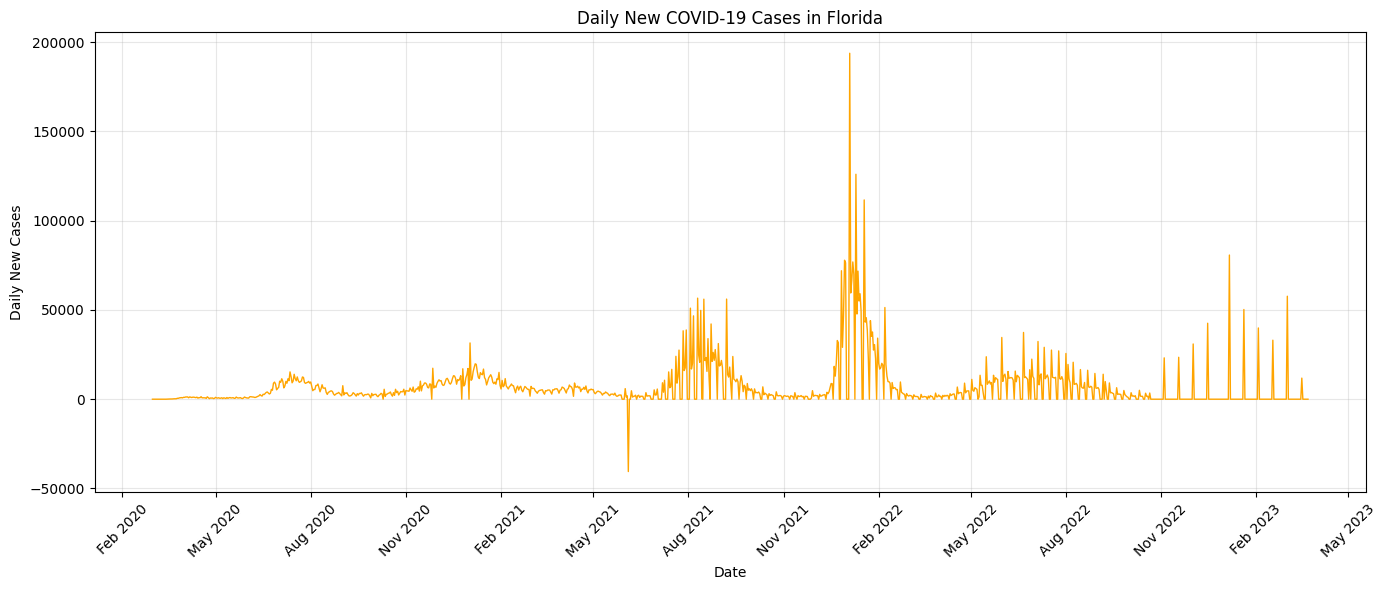

In [27]:
plt.figure(figsize=(14, 6))

plt.plot(
    florida_data["date"],
    florida_data["daily_cases"],
    color="orange",
    linewidth=1
)

plt.title("Daily New COVID-19 Cases in Florida")
plt.xlabel("Date")
plt.ylabel("Daily New Cases")
plt.grid(alpha=0.3)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("florida_daily_cases.png", dpi=300)
plt.show()